**Training Autoencoder**

In [1]:
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
import numpy as np
import matplotlib.pyplot as plt

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using Device: {device}")

embeddings = np.load('embeddings.npy')
X = torch.tensor(embeddings, dtype=torch.float32).to(device)

dataset = TensorDataset(X)
loader = DataLoader(dataset, batch_size=256, shuffle=True)

class Autoencoder(nn.Module):
    def __init__(self, input_dim=384, latent_dim=32):
        super().__init__()

        self.encoder = nn.Sequential(
            nn.Linear(input_dim, 256),
            nn.ReLU(),
            nn.BatchNorm1d(256),
            nn.Linear(256, 128),
            nn.ReLU(),
            nn.BatchNorm1d(128),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Linear(64, latent_dim)   
        )

        self.decoder = nn.Sequential(
            nn.Linear(latent_dim, 64),
            nn.ReLU(),
            nn.Linear(64, 128),
            nn.ReLU(),
            nn.BatchNorm1d(128),
            nn.Linear(128, 256),
            nn.ReLU(),
            nn.BatchNorm1d(256),
            nn.Linear(256, input_dim)
        )
    
    def forward(self, x):
        z = self.encoder(x)
        x_recon = self.decoder(z)
        return x_recon, z
    
    def encode(self, x):
        return self.encoder(x)


model = Autoencoder(input_dim=384, latent_dim=32).to(device)
print(model)
print(f"\nTotal paramters: {sum(p.numel() for p in model.parameters()):,}")

Using Device: cuda
Autoencoder(
  (encoder): Sequential(
    (0): Linear(in_features=384, out_features=256, bias=True)
    (1): ReLU()
    (2): BatchNorm1d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (3): Linear(in_features=256, out_features=128, bias=True)
    (4): ReLU()
    (5): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): Linear(in_features=128, out_features=64, bias=True)
    (7): ReLU()
    (8): Linear(in_features=64, out_features=32, bias=True)
  )
  (decoder): Sequential(
    (0): Linear(in_features=32, out_features=64, bias=True)
    (1): ReLU()
    (2): Linear(in_features=64, out_features=128, bias=True)
    (3): ReLU()
    (4): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (5): Linear(in_features=128, out_features=256, bias=True)
    (6): ReLU()
    (7): BatchNorm1d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (8): Linear(in_features=25

Epoch   5 / 50 | Loss: 0.002021
Epoch  10 / 50 | Loss: 0.001875
Epoch  15 / 50 | Loss: 0.001797
Epoch  20 / 50 | Loss: 0.001734
Epoch  25 / 50 | Loss: 0.001688
Epoch  30 / 50 | Loss: 0.001647
Epoch  35 / 50 | Loss: 0.001609
Epoch  40 / 50 | Loss: 0.001568
Epoch  45 / 50 | Loss: 0.001522
Epoch  50 / 50 | Loss: 0.001486


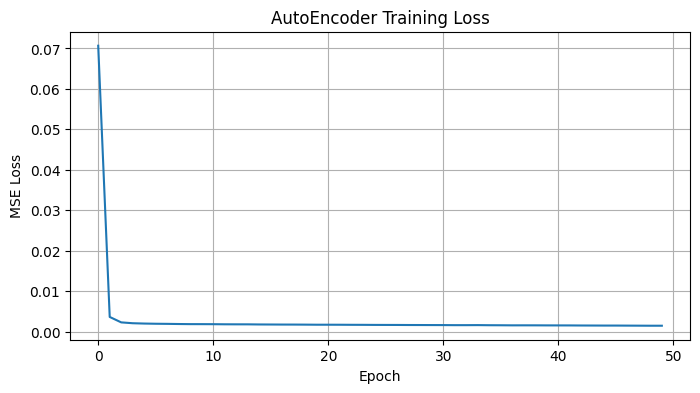

In [2]:
# Training
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-5)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, patience=5, factor=0.5
)
criterion = nn.MSELoss()

EPOCHS = 50
loss_history = []

for epoch in range(EPOCHS):
    model.train()
    epoch_loss = 0

    for (batch,) in loader:
        optimizer.zero_grad()
        recon, z = model(batch)
        loss = criterion(recon, batch)
        loss.backward()
        optimizer.step()
        epoch_loss += loss.item()

    avg_loss = epoch_loss/len(loader)
    loss_history.append(avg_loss)
    scheduler.step(avg_loss)

    if (epoch + 1) % 5 == 0 :
        print(f"Epoch {epoch+1:3d} / {EPOCHS} | Loss: {avg_loss:.6f}")

plt.figure(figsize=(8,4))
plt.plot(loss_history)
plt.xlabel('Epoch')
plt.ylabel('MSE Loss')
plt.title('AutoEncoder Training Loss')
plt.grid(True)
plt.savefig('autoencoder_loss.png', dpi=100)
plt.show()

In [3]:
# Extracting latent vectors 
model.eval()
with torch.no_grad():
    X_full = torch.tensor(embeddings, dtype=torch.float32).to(device)
    recon_full, Z = model(X_full)
    Z = Z.cpu().numpy()
    recon_full = recon_full.cpu().numpy()

print(f"Latent space shape: {Z.shape}")
# Expected: (7824, 32)

np.save('latent_vectors.npy', Z)

Latent space shape: (7824, 32)


In [4]:
# Running k-means to verify autoencoder effectiveness
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import StandardScaler

scaler_emb = StandardScaler()
scaler_z = StandardScaler()

X_scaled = scaler_emb.fit_transform(embeddings)
Z_scaled = scaler_z.fit_transform(Z)

# Fixed k for comparison 
K = 10

print("Running KMeans on raw embeddings....")
km_raw = KMeans(n_clusters=K, random_state=42, n_init=10)
labels_raw = km_raw.fit_predict(X_scaled)
sil_raw = silhouette_score(X_scaled, labels_raw, sample_size=2000)

print("Running Kmeans on latent vectors....")
km_latent = KMeans(n_clusters=K, random_state=42, n_init=10)
labels_latent = km_latent.fit_predict(Z_scaled)
sil_latent = silhouette_score(Z_scaled, labels_latent, sample_size=2000)

print(f"\nSilhouette Score for Raw embeddings (384d): {sil_raw:.4f}")
print(f"\nSilhouette Score for Latent vectors (384d): {sil_latent:.4f}")

Running KMeans on raw embeddings....
Running Kmeans on latent vectors....

Silhouette Score for Raw embeddings (384d): 0.0258

Silhouette Score for Latent vectors (384d): 0.2146


- Latent ≥ Raw -> autoencoder works fine 
- Latent < Raw by a small margin (< 0.02) -> IDEC joint training compensates for minor changes
- Latent << Raw (> 0.05 gap) -> autoencoder needs more epochs/architecture adjustment


On running epochs > 50 (~140-200) the latent vector silhouette score reduced to ~0.0776, although the training loss flattened out at 140-150 epochs, This indicates that the autoencoder is memorizing the data.

Hence to prevent cluster bleeding the epochs will be set to 50 and silhouette score will be considered to better evaluate cluster separation

In [5]:
# Reconstruction Sanity check
# Check how well the decoder reconstructs the original embeddings
import pandas as pd

data = pd.read_csv('reviews_preprocessed.csv')


recon_errors = np.mean((embeddings - recon_full) ** 2, axis=1)
print(f"Mean reconstruction error: {recon_errors.mean():.6f}")
print(f"Std reconstruction error:  {recon_errors.std():.6f}")
print(f"Max reconstruction error:  {recon_errors.max():.6f}") 

# Flagging outliers
outlier_threshold = recon_errors.mean() + 3 * recon_errors.std()
outliers = np.where(recon_errors > outlier_threshold)[0] 
print(f"\nHigh reconstruction error reviews: {len(outliers)}")
print("Sample outlier reviews:")
for idx in outliers[:3]:
    print(f"  [{idx}] {data['content_clean'].iloc[idx][:100]}")

Mean reconstruction error: 0.001467
Std reconstruction error:  0.000410
Max reconstruction error:  0.004250

High reconstruction error reviews: 29
Sample outlier reviews:
  [327] i paid for premium account but my account status is still free with no premium feature
  [1145] i paid for two account on two different device but at second device my premium membership can't be u
  [1146] i am a premium subscriber for 2 months i billed for october but my premium expired and app support i


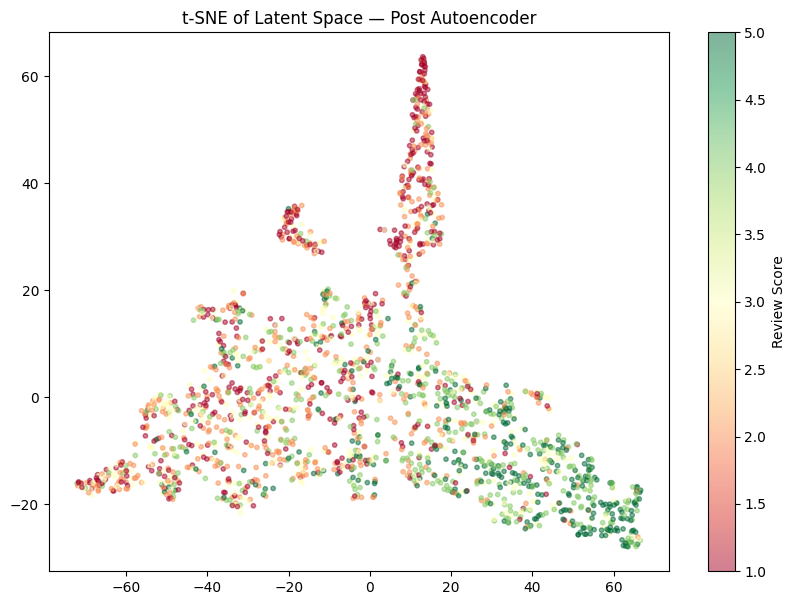

In [6]:
# T-SNE on latent space

from sklearn.manifold import TSNE

sample_idx = np.random.choice(len(Z), 2000, replace=False)
Z_sample = Z[sample_idx]
scores_sample = data['score'].iloc[sample_idx].values

tsne = TSNE(n_components=2, random_state=42, perplexity=30)
Z_2d = tsne.fit_transform(Z_sample)

plt.figure(figsize=(10,7))
scatter = plt.scatter(Z_2d[:, 0], Z_2d[:, 1], c=scores_sample, cmap='RdYlGn', alpha=0.5 , s=10)
plt.colorbar(scatter, label='Review Score')
plt.title('t-SNE of Latent Space — Post Autoencoder')
plt.savefig('tsne_phase3_latent.png', dpi=150)
plt.show()

In [7]:
# Saving model
torch.save({
    'model_state_dict': model.state_dict(),
    'optimizer_state_dict': optimizer.state_dict(),
    'loss_history': loss_history,
    'final_loss': loss_history[-1]
}, 'autoencoder_checkpoint.pt')

print(f"Model saved. Final loss: {loss_history[-1]:.6f}")

Model saved. Final loss: 0.001486


In [8]:
# For loading
"""checkpoint = torch.load('autoencoder_checkpoint.pt')
model.load_state_dict(checkpoint['model_state_dict'])
model.eval() """

"checkpoint = torch.load('autoencoder_checkpoint.pt')\nmodel.load_state_dict(checkpoint['model_state_dict'])\nmodel.eval() "